In [1]:
# Install required libraries
!pip install transformers      # Hugging Face library for BERT
!pip install torch            # PyTorch deep learning framework
!pip install pandas           # Data manipulation
!pip install numpy            # Numerical operations
!pip install scikit-learn     # ML utilities (metrics, splitting)
!pip install matplotlib       # Plotting
!pip install seaborn          # Enhanced visualizations
!pip install tqdm             # Progress bars

In [16]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import BertTokenizer, BertModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

print("✅ All imports successful!")
print(f"Transformers version: {__import__('transformers').__version__}")
print(f"Torch version: {torch.__version__}")

✅ All imports successful!
Transformers version: 5.16.1
Torch version: 2.11.0+cu128


In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')
else:
    print("⚠️ No GPU detected. Training will be slow.")

Using device: cuda
GPU: Tesla T4
Memory: 15.64 GB


In [18]:
def create_sample_dataset():
    positive_reviews = [
        "This movie was absolutely fantastic! Great acting and storyline.",
        "One of the best films I've ever seen. Highly recommended!",
        "Amazing cinematography and brilliant performances.",
        "A masterpiece that will stay with you long after watching.",
        "Incredible movie with a perfect blend of drama and action.",
        "Loved every minute of it. The director did an amazing job.",
        "Outstanding performances by the entire cast.",
        "A must-watch film that exceeds all expectations.",
        "Brilliant storytelling and excellent character development.",
        "This film is a work of art. Simply phenomenal."
    ] * 50

    negative_reviews = [
        "Terrible movie. Waste of time and money.",
        "Poor acting and confusing plot. Not recommended.",
        "One of the worst films I've ever seen.",
        "Boring and predictable. Couldn't wait for it to end.",
        "Disappointing and poorly executed.",
        "Bad script and worse direction. Avoid at all costs.",
        "A complete mess from start to finish.",
        "Unwatchable. I want my money back.",
        "Terrible dialogue and wooden performances.",
        "This movie is a disaster. Don't waste your time."
    ] * 50

    reviews = positive_reviews + negative_reviews
    labels = [1] * len(positive_reviews) + [0] * len(negative_reviews)
    return reviews, labels

reviews, labels = create_sample_dataset()
df = pd.DataFrame({'review': reviews, 'sentiment': labels})

print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:")
print(df['sentiment'].value_counts())
print(f"\nSample data:")
print(df.head())

Dataset shape: (1000, 2)

Class distribution:
sentiment
1    500
0    500
Name: count, dtype: int64

Sample data:
                                              review  sentiment
0  This movie was absolutely fantastic! Great act...          1
1  One of the best films I've ever seen. Highly r...          1
2  Amazing cinematography and brilliant performan...          1
3  A masterpiece that will stay with you long aft...          1
4  Incredible movie with a perfect blend of drama...          1


In [19]:
def preprocess_text(text):
    text = text.lower()
    text = ' '.join(text.split())
    return text

df['review'] = df['review'].apply(preprocess_text)

# 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    df['review'].values,
    df['sentiment'].values,
    test_size=0.3,
    random_state=SEED,
    stratify=df['sentiment'].values
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=SEED,
    stratify=y_temp
)

print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")

Training set size: 700
Validation set size: 150
Test set size: 150


In [28]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        # ✅ FIXED: call tokenizer directly (encode_plus is deprecated/removed)
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

print("✅ SentimentDataset class defined")

✅ SentimentDataset class defined


In [29]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

train_dataset = SentimentDataset(X_train, y_train, tokenizer)
val_dataset   = SentimentDataset(X_val, y_val, tokenizer)
test_dataset  = SentimentDataset(X_test, y_test, tokenizer)

BATCH_SIZE = 16
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Training batches:   {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches:       {len(test_loader)}")

Training batches:   44
Validation batches: 10
Test batches:       10


In [30]:
class BERTClassifier(nn.Module):
    def __init__(self, n_classes=2, dropout=0.3):
        super(BERTClassifier, self).__init__()
        # Base BERT model (no classification head built-in)
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, n_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output          # [CLS] token representation
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)
        return logits

model = BERTClassifier(n_classes=2)
model.to(device)

print("✅ Model initialized and moved to", device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model initialized and moved to cuda


In [31]:
model.eval()
with torch.no_grad():
    sample = tokenizer(
        "This is a test.",
        return_tensors='pt',
        padding='max_length',
        max_length=128,
        truncation=True
    )
    input_ids = sample['input_ids'].to(device)
    attention_mask = sample['attention_mask'].to(device)
    out = model(input_ids, attention_mask)
    print("Output shape:", out.shape)  # Expect: torch.Size([1, 2])
    print("✅ Model forward pass works!")

Output shape: torch.Size([1, 2])
✅ Model forward pass works!


In [32]:
def train_epoch(model, data_loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    correct_predictions = 0

    progress_bar = tqdm(data_loader, desc="Training")

    for batch in progress_bar:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = nn.CrossEntropyLoss()(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        predictions = torch.argmax(outputs, dim=1)
        correct_predictions += torch.sum(predictions == labels)

        progress_bar.set_postfix({'loss': loss.item()})

    accuracy = correct_predictions.double() / len(data_loader.dataset)
    avg_loss = total_loss / len(data_loader)
    return accuracy, avg_loss

print("✅ Training function defined")

✅ Training function defined


In [33]:
def evaluate(model, data_loader, device):
    model.eval()
    total_loss = 0
    correct_predictions = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        progress_bar = tqdm(data_loader, desc="Evaluating")

        for batch in progress_bar:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = nn.CrossEntropyLoss()(outputs, labels)

            total_loss += loss.item()
            predictions = torch.argmax(outputs, dim=1)
            correct_predictions += torch.sum(predictions == labels)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct_predictions.double() / len(data_loader.dataset)
    avg_loss = total_loss / len(data_loader)
    return accuracy, avg_loss, all_predictions, all_labels

print("✅ Evaluation function defined")

✅ Evaluation function defined


In [34]:
EPOCHS = 3
LEARNING_RATE = 2e-5

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

print(f"Total training steps: {total_steps}")
print(f"Warmup steps: {int(0.1 * total_steps)}")

Total training steps: 132
Warmup steps: 13


In [36]:
history = {'train_acc': [], 'train_loss': [], 'val_acc': [], 'val_loss': []}

best_accuracy = 0
best_model_state = None

for epoch in range(EPOCHS):
    print(f'\nEpoch {epoch + 1}/{EPOCHS}')
    print('-' * 50)

    train_acc, train_loss = train_epoch(model, train_loader, optimizer, scheduler, device)
    print(f'Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.4f}')

    val_acc, val_loss, _, _ = evaluate(model, val_loader, device)
    print(f'Val Loss: {val_loss:.4f} | Val Accuracy: {val_acc:.4f}')

    history['train_acc'].append(train_acc.item())
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc.item())
    history['val_loss'].append(val_loss)

    if val_acc > best_accuracy:
        best_accuracy = val_acc
        best_model_state = model.state_dict().copy()
        print(f'✓ New best model saved (accuracy: {best_accuracy:.4f})')

if best_model_state:
    model.load_state_dict(best_model_state)
    print(f'\n✅ Loaded best model with accuracy: {best_accuracy:.4f}')


Epoch 1/3
--------------------------------------------------


Training: 100%|██████████| 44/44 [00:19<00:00,  2.29it/s, loss=0.0153]


Train Loss: 0.3229 | Train Accuracy: 0.8700


Evaluating: 100%|██████████| 10/10 [00:01<00:00,  6.64it/s]


Val Loss: 0.0102 | Val Accuracy: 1.0000
✓ New best model saved (accuracy: 1.0000)

Epoch 2/3
--------------------------------------------------


...

Val Loss: 0.0015 | Val Accuracy: 1.0000

Epoch 3/3
--------------------------------------------------


Training: 100%|██████████| 44/44 [00:17<00:00,  2.46it/s, loss=0.00185]


Train Loss: 0.0020 | Train Accuracy: 1.0000


Evaluating: 100%|██████████| 10/10 [00:01<00:00,  6.40it/s]

Val Loss: 0.0012 | Val Accuracy: 1.0000

✅ Loaded best model with accuracy: 1.0000


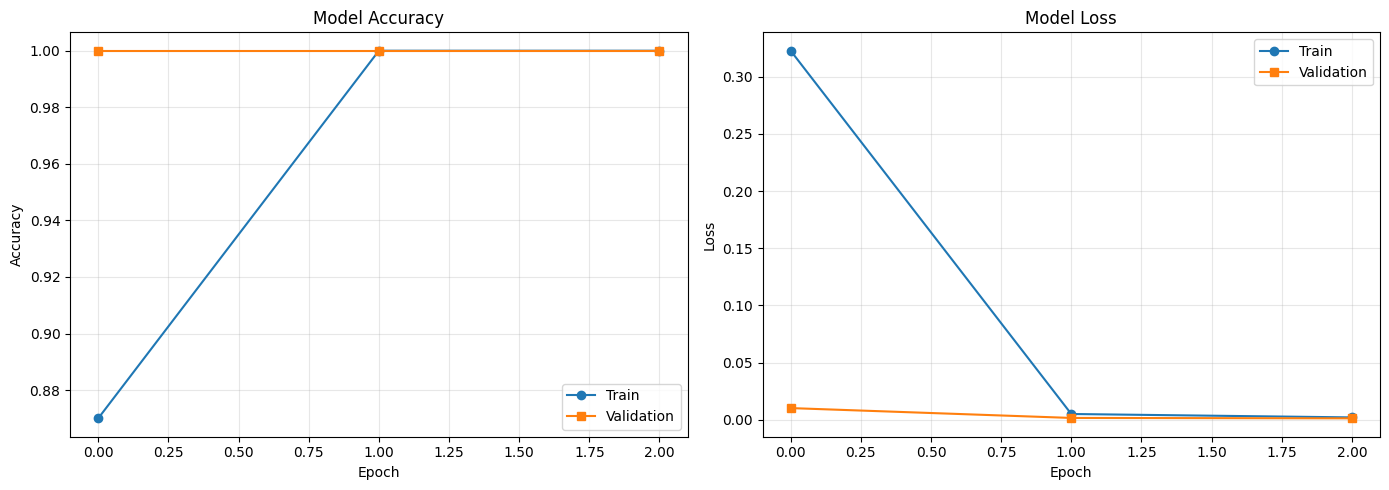

In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_acc'], label='Train', marker='o')
ax1.plot(history['val_acc'],   label='Validation', marker='s')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.set_title('Model Accuracy'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history['train_loss'], label='Train', marker='o')
ax2.plot(history['val_loss'],   label='Validation', marker='s')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.set_title('Model Loss'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
print("Evaluating on Test Set...")
test_acc, test_loss, test_predictions, test_labels = evaluate(model, test_loader, device)
print(f'\nTest Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

Evaluating on Test Set...


Evaluating: 100%|██████████| 10/10 [00:01<00:00,  7.34it/s]


Test Loss: 0.0012
Test Accuracy: 1.0000


In [39]:
print("\nClassification Report:")
print(classification_report(
    test_labels,
    test_predictions,
    target_names=['Negative', 'Positive']
))


Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        75
    Positive       1.00      1.00      1.00        75

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150



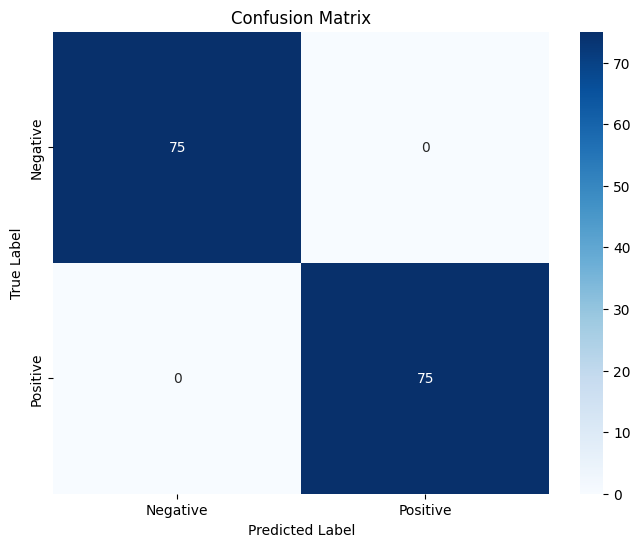

In [40]:
cm = confusion_matrix(test_labels, test_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [41]:
def predict_sentiment(text, model, tokenizer, device, max_length=128):
    model.eval()
    text = preprocess_text(text)

    # ✅ Yahan bhi encode_plus nahi, direct tokenizer call
    encoding = tokenizer(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probabilities = torch.softmax(outputs, dim=1)
        prediction = torch.argmax(outputs, dim=1)

    sentiment = 'Positive' if prediction.item() == 1 else 'Negative'
    confidence = probabilities[0][prediction.item()].item()
    return sentiment, confidence, probabilities.cpu().numpy()[0]

print("✅ Prediction function ready")

✅ Prediction function ready


In [42]:
sample_texts = [
    "This movie was absolutely amazing! I loved every minute of it.",
    "Terrible film. Complete waste of time.",
    "It was okay, not great but not terrible either.",
    "The acting was superb and the plot kept me engaged throughout.",
    "I fell asleep halfway through. Boring and predictable."
]

print("Testing Predictions on Sample Texts:")
print("=" * 80)

for text in sample_texts:
    sentiment, confidence, probs = predict_sentiment(text, model, tokenizer, device)
    print(f"\nText: {text}")
    print(f"Predicted Sentiment: {sentiment}")
    print(f"Confidence: {confidence:.4f}")
    print(f"Probabilities: Negative={probs[0]:.4f}, Positive={probs[1]:.4f}")
    print("-" * 80)

Testing Predictions on Sample Texts:

Text: This movie was absolutely amazing! I loved every minute of it.
Predicted Sentiment: Positive
Confidence: 0.9982
Probabilities: Negative=0.0018, Positive=0.9982
--------------------------------------------------------------------------------

Text: Terrible film. Complete waste of time.
Predicted Sentiment: Negative
Confidence: 0.9990
Probabilities: Negative=0.9990, Positive=0.0010
--------------------------------------------------------------------------------

Text: It was okay, not great but not terrible either.
Predicted Sentiment: Negative
Confidence: 0.8545
Probabilities: Negative=0.8545, Positive=0.1455
--------------------------------------------------------------------------------

Text: The acting was superb and the plot kept me engaged throughout.
Predicted Sentiment: Positive
Confidence: 0.9959
Probabilities: Negative=0.0041, Positive=0.9959
--------------------------------------------------------------------------------

Text: I f

In [43]:
model_save_path = 'bert_sentiment_model.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history,
    'best_accuracy': best_accuracy
}, model_save_path)

tokenizer.save_pretrained('bert_sentiment_tokenizer')

print(f"✅ Model saved to {model_save_path}")
print("✅ Tokenizer saved to bert_sentiment_tokenizer/")

✅ Model saved to bert_sentiment_model.pth
✅ Tokenizer saved to bert_sentiment_tokenizer/


In [44]:
def load_model(model_path, tokenizer_path, device):
    model = BERTClassifier(n_classes=2)
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    tokenizer = BertTokenizer.from_pretrained(tokenizer_path)
    return model, tokenizer

# Test it
# loaded_model, loaded_tokenizer = load_model(
#     'bert_sentiment_model.pth',
#     'bert_sentiment_tokenizer',
#     device
# )
print("✅ Load function defined")

✅ Load function defined
